# Exploring minima of the Janus lattice

This notebook explores the distribution of minima of homsets of supersingular elliptic curves with scalar level structure. To run it you will need the following python packages:

In [1]:
import pandas as pd, numpy as np, gzip
from matplotlib import pyplot as plt

The dataset was pre-generated. To generate a new one, install Sagemath and then run

```
./sample_mt.py <how_many> -p<char> -g<mod>
```

This generates `<how_many>` random ideal classes of B_p,∞ with `p = <char>` and prints the 4 minima of the associated quadratic form, normalized by √p, and the associated Gram matrix modulo `<mod>`.

In [2]:
# parse the data into a Pandas dataframe
with gzip.open('p2e62_janus.csv.gz', 'rt') as f:
    # first line is a (useful) comment
    for i in range(1):
        print(next(f))
    df = pd.read_csv(f, names=[f'm{i}' for i in range(1,5)], dtype=float)

# ['./sample_mt.py', '1000000', '-p4611686018427388039', '-2']



## The minima

Remember the first 3 minima are divided by $p^⅓ / 2$, while the 4th is divided by $p/4$

In [3]:
df.describe()

,m1,m2,m3,m4
count,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,0.622943,1.475491,5.340294,1.000000e+00
std,0.325429,0.919895,49.800665,4.553746e-12
min,0.000103,0.012161,1.273364,1.000000e+00
25%,0.361385,1.063888,2.022357,1.000000e+00
50%,0.608915,1.340472,2.789477,1.000000e+00
75%,0.870907,1.646530,4.560436,1.000000e+00
max,1.546903,114.653053,34364.175031,1.000000e+00


1st minimum, familiar shape of distribution

<Axes: >

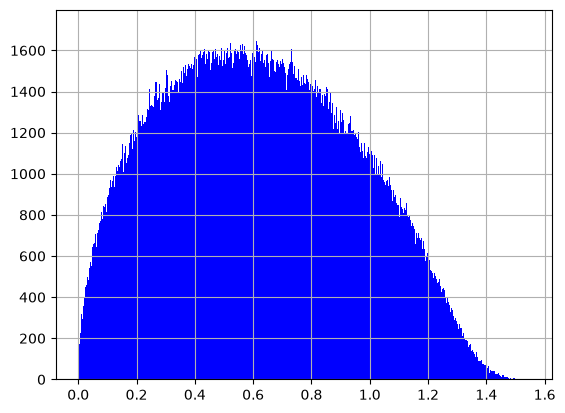

In [4]:
df['m1'].hist(bins=1000, color='blue')

first 3 minima, in log scale

<Axes: >

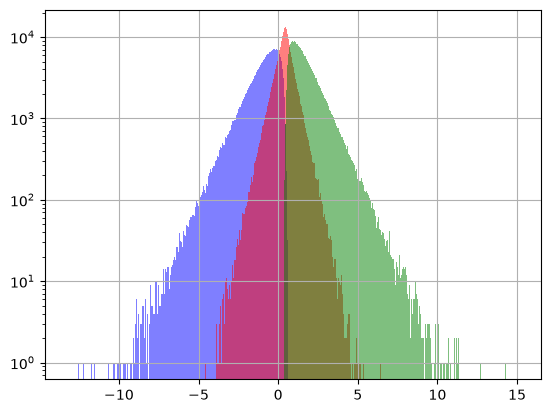

In [5]:
np.log2(df['m1']).hist(bins=1000, color='blue', alpha=0.5, log=True)
np.log2(df['m2']).hist(bins=1000, color='red', alpha=0.5, log=True)
np.log2(df['m3']).hist(bins=1000, color='green', alpha=0.5, log=True)

The 4th minimum is essentially p/4

<Axes: >

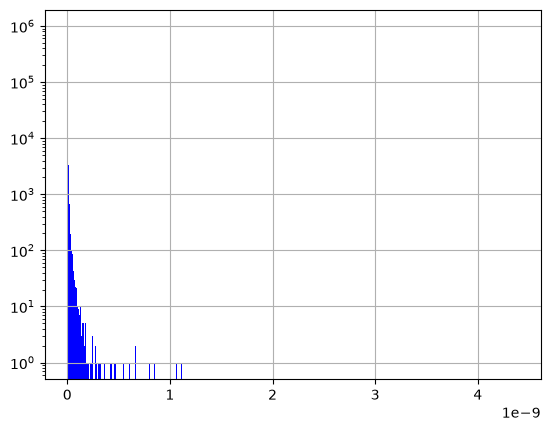

In [6]:
np.log2(df['m4']).hist(bins=1000, color='blue', log=True)

Maybe not so surprising, there's a decent correlation between 1st and 3rd minimum

<Axes: >

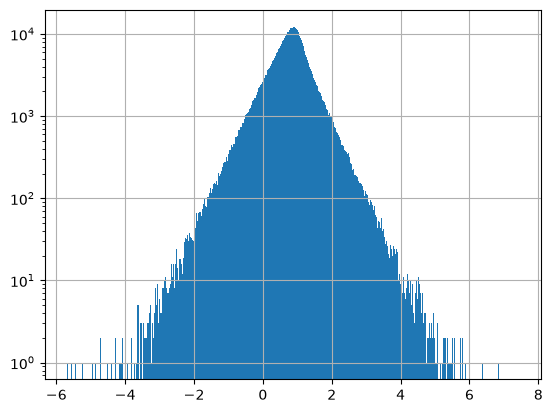

In [7]:
np.log2(df['m1']*df['m3']).hist(bins=1000, log=True)

In [8]:
df['i2'] = 1/df['m2']
df['i3'] = 1/df['m3']
df['prod'] = df['m1'] * df['m2'] * df['m3']
df.corr()

,m1,m2,m3,m4,i2,i3,prod
m1,1.000000,-0.292943,-0.087836,-0.097432,-0.067157,0.864909,0.644444
m2,-0.292943,1.000000,-0.019313,-0.006771,-0.503254,-0.018007,-0.017860
m3,-0.087836,-0.019313,1.000000,0.497914,0.389401,-0.105022,-0.049980
m4,-0.097432,-0.006771,0.497914,1.000000,0.338022,-0.112530,-0.055937
i2,-0.067157,-0.503254,0.389401,0.338022,1.000000,-0.359826,-0.130008
i3,0.864909,-0.018007,-0.105022,-0.112530,-0.359826,1.000000,0.547455
prod,0.644444,-0.017860,-0.049980,-0.055937,-0.130008,0.547455,1.000000


<Axes: xlabel='m1', ylabel='i3'>

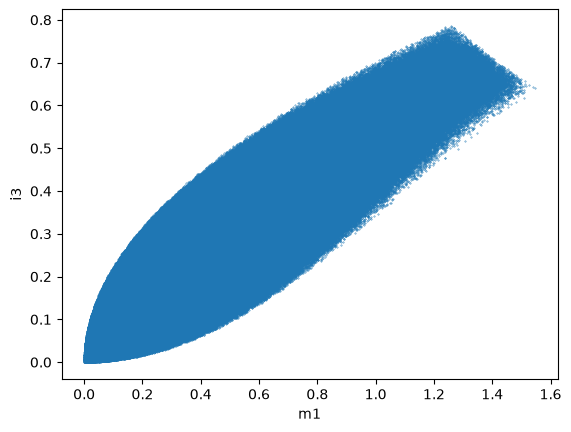

In [9]:
df.plot('m1', 'i3', kind='scatter', s=0.1)

Usual quantile analysis in geometric progressoin (ratio 2)

In [10]:
df.quantile([1-1/2**i for i in range(1,21)])

,m1,m2,m3,m4,i2,i3,prod
0.500000,0.608915,1.340472,2.789477,1.0,0.746006,0.358490,2.209748
0.750000,0.870907,1.646530,4.560436,1.0,0.939948,0.494473,2.390085
0.875000,1.036122,2.040181,7.284237,1.0,1.185509,0.572273,2.543092
0.937500,1.146290,2.547023,11.605169,1.0,1.494908,0.620892,2.677775
0.968750,1.223079,3.185034,18.387727,1.0,1.880846,0.654018,2.806007
0.984375,1.279178,4.001850,29.030841,1.0,2.359141,0.679075,2.927413
0.992188,1.322781,5.036877,46.015005,1.0,2.976476,0.699115,3.038550
0.996094,1.358874,6.336732,72.655988,1.0,3.763974,0.714716,3.138793
0.998047,1.389809,7.995383,116.223976,1.0,4.712211,0.727953,3.230436
0.999023,1.415732,10.094306,189.024747,1.0,5.961917,0.739095,3.311435


In [11]:
df.quantile([1-1/2**i for i in range(1,21)]).pct_change()

,m1,m2,m3,m4,i2,i3,prod
0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.750000,0.430261,0.228321,0.634871,2.429168e-13,0.259974,0.379320,0.081610
0.875000,0.189705,0.239080,0.597268,3.370637e-13,0.261249,0.157341,0.064017
0.937500,0.106327,0.248430,0.593189,5.289102e-13,0.260984,0.084956,0.052960
0.968750,0.066989,0.250493,0.584443,8.451018e-13,0.258169,0.053353,0.047888
0.984375,0.045867,0.256454,0.578816,1.332934e-12,0.254298,0.038312,0.043266
0.992188,0.034086,0.258637,0.585039,2.084555e-12,0.261678,0.029512,0.037964
0.996094,0.027286,0.258068,0.578963,3.319123e-12,0.264574,0.022315,0.032990
0.998047,0.022765,0.261752,0.599648,5.396572e-12,0.251924,0.018521,0.029197
0.999023,0.018652,0.262517,0.626383,8.976375e-12,0.265206,0.015305,0.025074


In [13]:
import pandas as pd, numpy as np, gzip
from matplotlib import pyplot as plt
from scipy.stats import norm
import math

In [17]:
d = np.sort(1/df['m1'].dropna().to_numpy()) 
n = len(d) 
alpha0 = 1.5
rows = [] 
perc_span = np.linspace(0.001, 0.1, 100) 

for perc in perc_span:
    k = math.ceil(perc*n)
    u = d[-k-1]
    tail = d[-k:]
    gamma_hat = np.mean(np.log(tail / u))
    alpha_hat = 1 / gamma_hat
    
    se = alpha_hat / math.sqrt(k)
    
    # Test H0: alpha = 4 using the Hill asymptotic normal approximation
    se0 = alpha0 / math.sqrt(k)
    z = (alpha_hat - alpha0) / se0
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    rows.append({
        "k": k,
        "perc": perc,
        "threshold": u,
        "alpha_hat": alpha_hat,
        "ci_low": alpha_hat - 1.96 * se,
        "ci_high": alpha_hat + 1.96 * se,
        "z_alpha_eq_alpha0": z,
        "p_value_alpha_eq_alpha0": p_value,
        "C_hat_alpha0": (k / n) * u**4,
    })

out = pd.DataFrame(rows)
out

,k,perc,threshold,alpha_hat,ci_low,ci_high,z_alpha_eq_alpha0,p_value_alpha_eq_alpha0,C_hat_alpha0
0,1000,0.001,115.079552,1.424146,1.335877,1.512416,-1.599133,0.109791,175385.084243
1,2000,0.002,72.534018,1.475598,1.410927,1.540269,-0.727520,0.466908,55360.109319
2,3000,0.003,54.417113,1.454859,1.402798,1.506920,-1.648317,0.099288,26306.510086
3,4000,0.004,44.943046,1.466755,1.421300,1.512210,-1.401722,0.160998,16319.618339
4,5000,0.005,38.910436,1.482986,1.441879,1.524092,-0.802060,0.422518,11461.313925
...,...,...,...,...,...,...,...,...,...
95,96000,0.096,5.382411,1.487385,1.477976,1.496794,-2.605685,0.009169,80.570991
96,97000,0.097,5.342676,1.486411,1.477056,1.495765,-2.821573,0.004779,79.032737
97,98000,0.098,5.306702,1.486729,1.477421,1.496038,-2.769594,0.005613,77.718562
98,99000,0.099,5.269807,1.486407,1.477148,1.495666,-2.851335,0.004354,76.350868


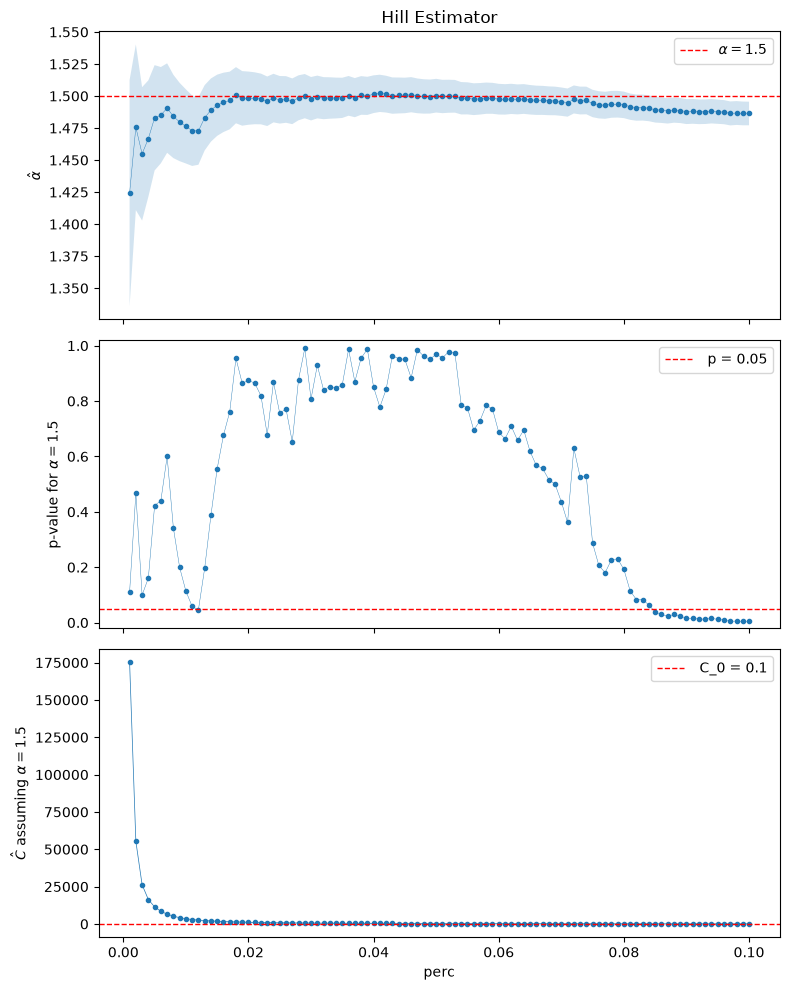

In [18]:
title = 'Hill Estimator'
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax = axes[0]
ax.plot(out["perc"], out["alpha_hat"], marker=".", linewidth=0.3)
ax.fill_between(out["perc"], out["ci_low"], out["ci_high"], alpha=0.2)
ax.axhline(alpha0, color="red", linestyle="--", linewidth=1, label=fr"$\alpha={alpha0}$")
ax.set_ylabel(r"$\hat\alpha$")
ax.set_title(title or "Hill tail diagnostics")
ax.legend()

ax = axes[1]
ax.plot(out["perc"], out["p_value_alpha_eq_alpha0"], marker=".", linewidth=0.3)
p = 0.05
ax.axhline(p, color="red", linestyle="--", linewidth=1, label=f"{ p = }")
ax.set_ylabel(fr"p-value for $\alpha={alpha0}$")
ax.set_ylim(-0.02, 1.02)
ax.legend()

ax = axes[2]
ax.plot(out["perc"], out["C_hat_alpha0"], marker=".", linewidth=0.5)
C_0 = 0.1
ax.axhline(C_0, color="red", linestyle="--", linewidth=1, label=f"{ C_0 = }")
ax.set_ylabel(fr"$\hat C$ assuming $\alpha={alpha0}$")
ax.set_xlabel("perc")
ax.legend()

plt.tight_layout()
plt.show()
